In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, auc, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import seaborn as sns

# --- Cihaz Ayarı (GPU/CPU) ---
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple M4 GPU (MPS) hızlandırması aktif.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA GPU hızlandırması aktif.")
else:
    device = torch.device("cpu")
    print("CPU kullanılacak.")

# --- 1. Veri Setini Yükleme ---
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes',
            'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
            'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
            'num_shells','num_access_files','num_outbound_cmds','is_host_login',
            'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
            'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
            'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
            'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
            'dst_host_rerror_rate','dst_host_srv_rerror_rate','attack','level'])

train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df = pd.read_csv('KDDTest+.txt', names=columns)
train_df.drop('level', axis=1, inplace=True)
test_df.drop('level', axis=1, inplace=True)

# --- 2. Etiketleri Düzenleme (Normal = 0, Saldırı = 1) ---
train_df['attack'] = train_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['attack'] = test_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)

y_train = train_df['attack'].values
y_test = test_df['attack'].values
train_df.drop('attack', axis=1, inplace=True)
test_df.drop('attack', axis=1, inplace=True)

# --- 3. Kategorik Verileri Sayısallaştırma (One-Hot Encoding) ---
categorical_cols = ['protocol_type', 'service', 'flag']
combined_df = pd.concat([train_df, test_df])
combined_df = pd.get_dummies(combined_df, columns=categorical_cols, dtype=float)

X_train_all = combined_df.iloc[:len(train_df)].values
X_test_all = combined_df.iloc[len(train_df):].values

# --- 4. Ölçeklendirme ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled = scaler.transform(X_test_all)

# --- 5. VAE İçin Veri Hazırlığı ---
# VAE sadece NORMAL verilerle eğitilecek
X_normal = X_train_scaled[y_train == 0]

# Normal veriyi %80 eğitim, %20 doğrulama olarak ayır
X_train_vae, X_val_vae = train_test_split(X_normal, test_size=0.2, random_state=42)

# PyTorch Tensor'larına çevir
X_train_t = torch.tensor(X_train_vae, dtype=torch.float32)
X_val_t = torch.tensor(X_val_vae, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# DataLoader
batch_size = 256
train_loader = DataLoader(TensorDataset(X_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t), batch_size=batch_size, shuffle=False)

input_dim = X_train_t.shape[1]
print(f"\nÖzellik sayısı: {input_dim}")
print(f"VAE Eğitim (Normal): {len(X_train_t)}")
print(f"VAE Doğrulama (Normal): {len(X_val_t)}")
print(f"Test: {len(X_test_t)} (Normal: {(y_test==0).sum()}, Saldırı: {(y_test==1).sum()})")

Apple M4 GPU (MPS) hızlandırması aktif.

Özellik sayısı: 122
VAE Eğitim (Normal): 53874
VAE Doğrulama (Normal): 13469
Test: 22544 (Normal: 9711, Saldırı: 12833)


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, auc, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import seaborn as sns

# --- Cihaz Ayarı (GPU/CPU) ---
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple M4 GPU (MPS) hızlandırması aktif.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA GPU hızlandırması aktif.")
else:
    device = torch.device("cpu")
    print("CPU kullanılacak.")

# --- 1. Veri Setini Yükleme ---
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes',
            'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
            'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
            'num_shells','num_access_files','num_outbound_cmds','is_host_login',
            'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
            'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
            'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
            'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
            'dst_host_rerror_rate','dst_host_srv_rerror_rate','attack','level'])

train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df = pd.read_csv('KDDTest+.txt', names=columns)
train_df.drop('level', axis=1, inplace=True)
test_df.drop('level', axis=1, inplace=True)

# --- 2. Etiketleri Düzenleme (Normal = 0, Saldırı = 1) ---
train_df['attack'] = train_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['attack'] = test_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)

y_train = train_df['attack'].values
y_test = test_df['attack'].values
train_df.drop('attack', axis=1, inplace=True)
test_df.drop('attack', axis=1, inplace=True)

# --- 3. Kategorik Verileri Sayısallaştırma (One-Hot Encoding) ---
categorical_cols = ['protocol_type', 'service', 'flag']
combined_df = pd.concat([train_df, test_df])
combined_df = pd.get_dummies(combined_df, columns=categorical_cols, dtype=float)

X_train_all = combined_df.iloc[:len(train_df)].values
X_test_all = combined_df.iloc[len(train_df):].values

# --- 4. Ölçeklendirme ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled = scaler.transform(X_test_all)

# --- 5. VAE İçin Veri Hazırlığı ---
# VAE sadece NORMAL verilerle eğitilecek
X_normal = X_train_scaled[y_train == 0]

# Normal veriyi %80 eğitim, %20 doğrulama olarak ayır
X_train_vae, X_val_vae = train_test_split(X_normal, test_size=0.2, random_state=42)

# PyTorch Tensor'larına çevir
X_train_t = torch.tensor(X_train_vae, dtype=torch.float32)
X_val_t = torch.tensor(X_val_vae, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# DataLoader
batch_size = 256
train_loader = DataLoader(TensorDataset(X_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t), batch_size=batch_size, shuffle=False)

input_dim = X_train_t.shape[1]
print(f"\nÖzellik sayısı: {input_dim}")
print(f"VAE Eğitim (Normal): {len(X_train_t)}")
print(f"VAE Doğrulama (Normal): {len(X_val_t)}")
print(f"Test: {len(X_test_t)} (Normal: {(y_test==0).sum()}, Saldırı: {(y_test==1).sum()})")

Apple M4 GPU (MPS) hızlandırması aktif.

Özellik sayısı: 122
VAE Eğitim (Normal): 53874
VAE Doğrulama (Normal): 13469
Test: 22544 (Normal: 9711, Saldırı: 12833)


In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
        super(VAE, self).__init__()
        # Encoder: Veriyi sıkıştırma
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU()
        )
        # Latent uzay parametreleri
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)       # Ortalama (μ)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)   # Log-Varyans
        # Decoder: Veriyi yeniden oluşturma
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        """Reparameterization Trick: z = mu + std * epsilon"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss_fn(recon_x, x, mu, logvar, beta=1.0):
    """VAE kayıp fonksiyonu: Rekonstrüksiyon hatası + KL Divergence"""
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


# Model oluştur
model = VAE(input_dim, hidden_dim=64, latent_dim=16).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print(model)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=122, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=32, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=32, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=122, bias=True)
  )
)


VAE Eğitimi Başlıyor (Sadece Normal Trafik Verileri)...

Epoch [10/50] | Train Loss: 23.1509 | Val Loss: 33.3091
Epoch [20/50] | Train Loss: 16.6708 | Val Loss: 31.9802
Epoch [30/50] | Train Loss: 13.5137 | Val Loss: 26.7555
Epoch [40/50] | Train Loss: 12.9562 | Val Loss: 26.4929
Epoch [50/50] | Train Loss: 13.8829 | Val Loss: 26.9004


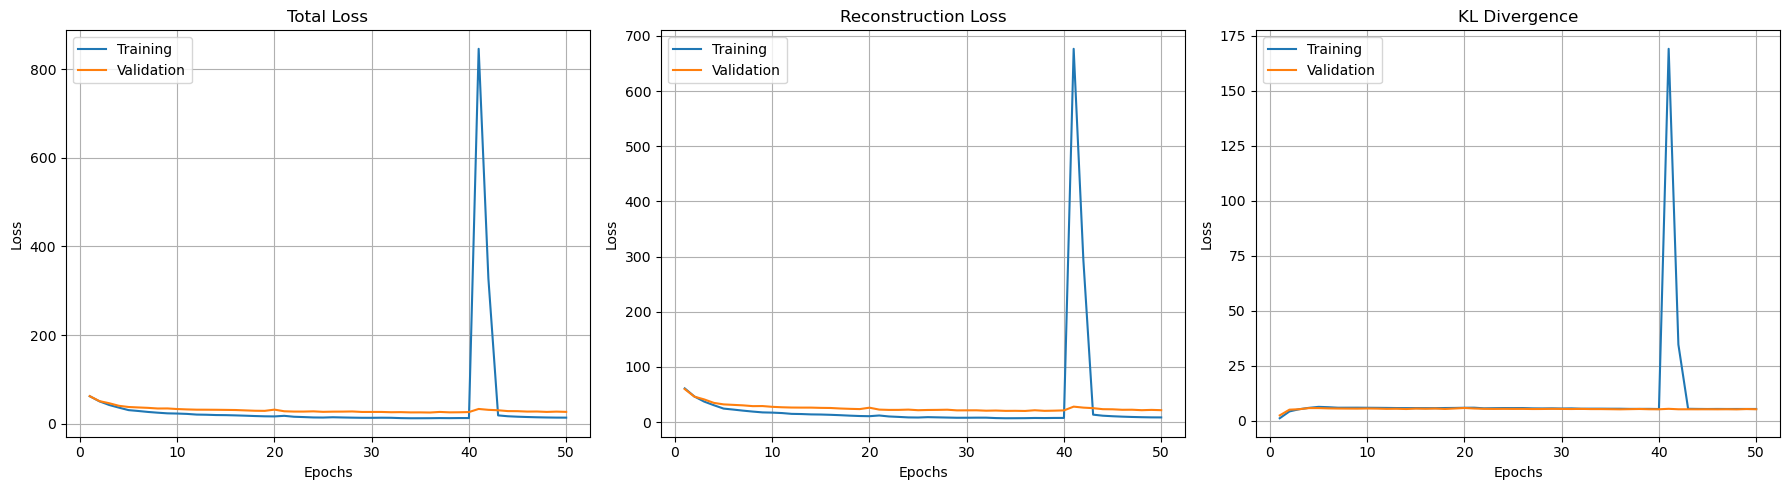

In [4]:
epochs = 50
beta = 1.0  # KL ağırlık katsayısı

history = {'train_total': [], 'train_recon': [], 'train_kl': [],
           'val_total': [], 'val_recon': [], 'val_kl': []}

print("VAE Eğitimi Başlıyor (Sadece Normal Trafik Verileri)...\n")

for epoch in range(epochs):
    # --- Eğitim ---
    model.train()
    t_loss, t_recon, t_kl = 0.0, 0.0, 0.0
    for (x,) in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss, recon, kl = vae_loss_fn(x_recon, x, mu, logvar, beta)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
        t_recon += recon.item()
        t_kl += kl.item()

    n_train = len(train_loader.dataset)
    history['train_total'].append(t_loss / n_train)
    history['train_recon'].append(t_recon / n_train)
    history['train_kl'].append(t_kl / n_train)

    # --- Doğrulama ---
    model.eval()
    v_loss, v_recon, v_kl = 0.0, 0.0, 0.0
    with torch.no_grad():
        for (x,) in val_loader:
            x = x.to(device)
            x_recon, mu, logvar = model(x)
            loss, recon, kl = vae_loss_fn(x_recon, x, mu, logvar, beta)
            v_loss += loss.item()
            v_recon += recon.item()
            v_kl += kl.item()

    n_val = len(val_loader.dataset)
    history['val_total'].append(v_loss / n_val)
    history['val_recon'].append(v_recon / n_val)
    history['val_kl'].append(v_kl / n_val)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {history['train_total'][-1]:.4f} | "
              f"Val Loss: {history['val_total'][-1]:.4f}")

# --- Eğitim Grafikleri ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, epochs + 1)

axes[0].plot(ep, history['train_total'], label='Training')
axes[0].plot(ep, history['val_total'], label='Validation')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ep, history['train_recon'], label='Training')
axes[1].plot(ep, history['val_recon'], label='Validation')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(ep, history['train_kl'], label='Training')
axes[2].plot(ep, history['val_kl'], label='Validation')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

Normal Trafik  - Ort. Hata: 0.065011 (±0.487963)
Saldırı Trafik - Ort. Hata: 1.208892 (±8.810571)


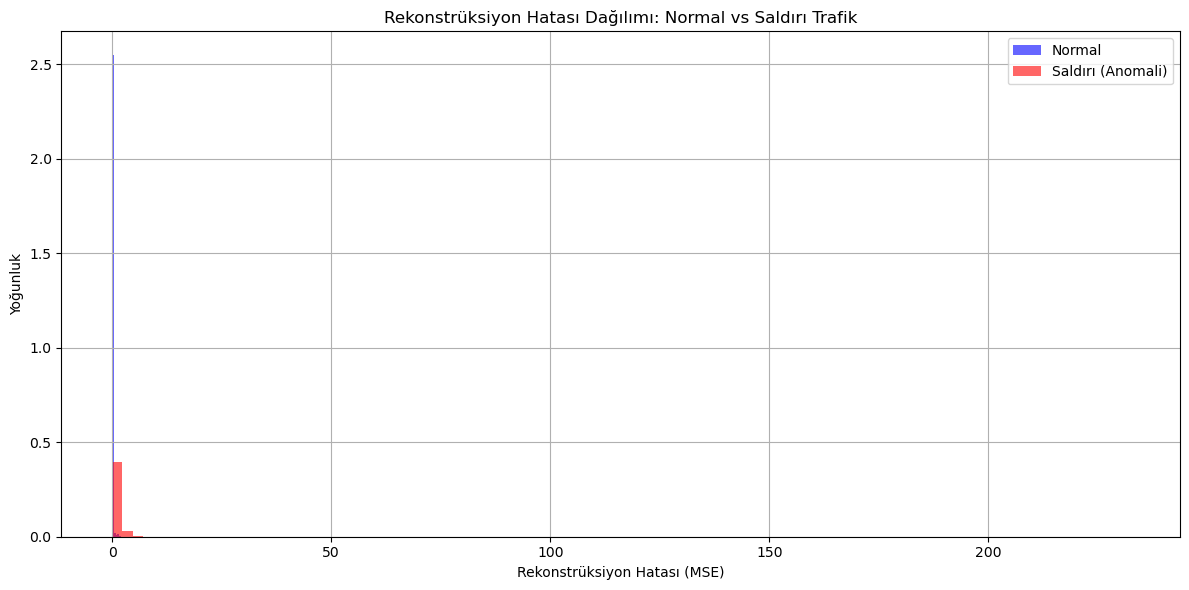

In [5]:
def compute_recon_errors(model, data, device, batch_size=256):
    """Her örnek için deterministik rekonstrüksiyon hatası (MSE) hesapla.
       Anomali tespiti için sadece mu (ortalama) kullanılır, örnekleme yapılmaz."""
    model.eval()
    errors = []
    loader = DataLoader(TensorDataset(data), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            mu, _ = model.encode(x)
            x_recon = model.decode(mu)  # Deterministik rekonstrüksiyon
            mse = torch.mean((x - x_recon) ** 2, dim=1)
            errors.extend(mse.cpu().numpy())
    return np.array(errors)

# Test seti üzerinde rekonstrüksiyon hataları
test_errors = compute_recon_errors(model, X_test_t, device)

normal_errors = test_errors[y_test == 0]
attack_errors = test_errors[y_test == 1]

print(f"Normal Trafik  - Ort. Hata: {normal_errors.mean():.6f} (±{normal_errors.std():.6f})")
print(f"Saldırı Trafik - Ort. Hata: {attack_errors.mean():.6f} (±{attack_errors.std():.6f})")

# --- Rekonstrüksiyon Hatası Dağılım Grafiği ---
plt.figure(figsize=(12, 6))
plt.hist(normal_errors, bins=100, alpha=0.6, label='Normal', density=True, color='blue')
plt.hist(attack_errors, bins=100, alpha=0.6, label='Saldırı (Anomali)', density=True, color='red')
plt.xlabel('Rekonstrüksiyon Hatası (MSE)')
plt.ylabel('Yoğunluk')
plt.title('Rekonstrüksiyon Hatası Dağılımı: Normal vs Saldırı Trafik')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

ROC-AUC: 0.9467
En İyi Eşik Değeri (Threshold): 0.165810
Bu eşikte - TPR: 0.8714, FPR: 0.0918


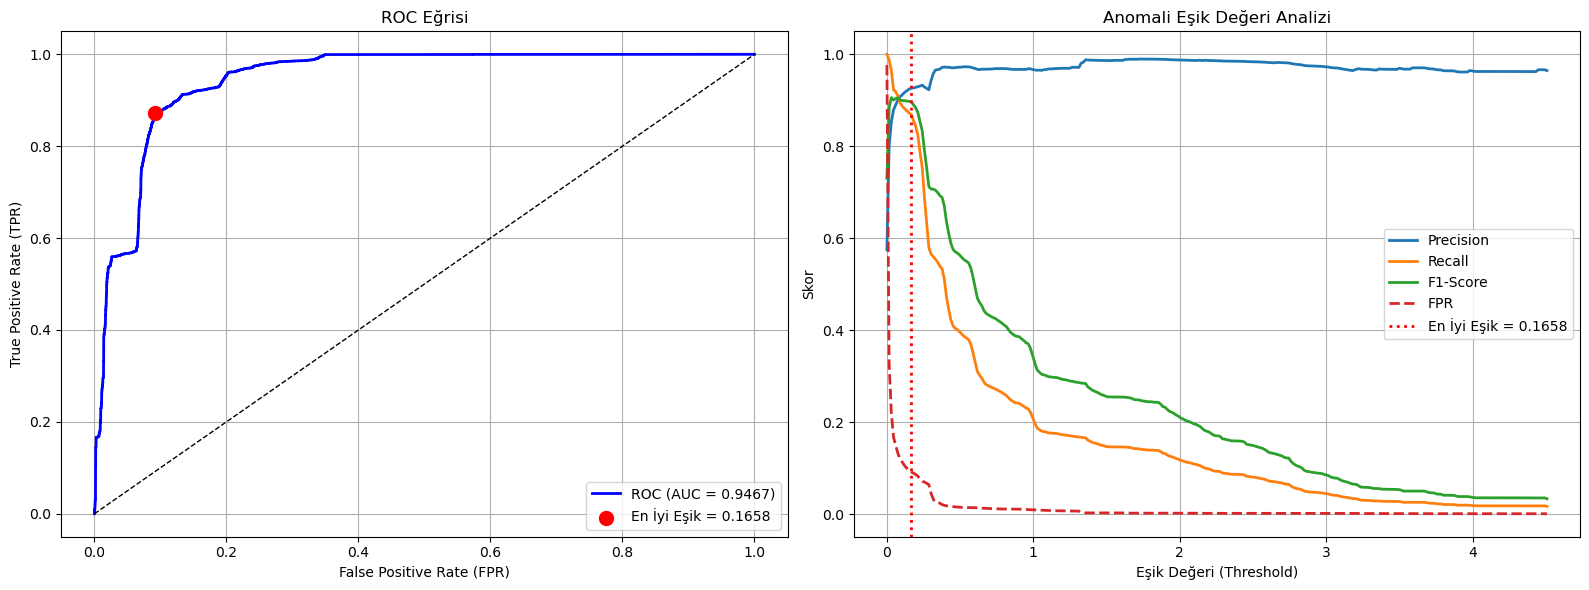

In [6]:
# --- ROC Eğrisi ---
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, test_errors)
roc_auc_val = auc(fpr_arr, tpr_arr)

# En iyi eşik değeri (Youden's J = TPR - FPR)
j_scores = tpr_arr - fpr_arr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"ROC-AUC: {roc_auc_val:.4f}")
print(f"En İyi Eşik Değeri (Threshold): {best_threshold:.6f}")
print(f"Bu eşikte - TPR: {tpr_arr[best_idx]:.4f}, FPR: {fpr_arr[best_idx]:.4f}")

# --- Eşik Değeri Analizi ---
th_range = np.linspace(np.percentile(test_errors, 1),
                       np.percentile(test_errors, 99), 300)
m = {'precision': [], 'recall': [], 'f1': [], 'fpr': []}

for t in th_range:
    yp = (test_errors > t).astype(int)
    tp = np.sum((yp == 1) & (y_test == 1))
    fp = np.sum((yp == 1) & (y_test == 0))
    fn = np.sum((yp == 0) & (y_test == 1))
    tn = np.sum((yp == 0) & (y_test == 0))
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    fv = fp / (fp + tn) if (fp + tn) > 0 else 0
    m['precision'].append(p)
    m['recall'].append(r)
    m['f1'].append(f)
    m['fpr'].append(fv)

# --- Grafikler ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Eğrisi
axes[0].plot(fpr_arr, tpr_arr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].scatter(fpr_arr[best_idx], tpr_arr[best_idx], c='red', s=100, zorder=5,
               label=f'En İyi Eşik = {best_threshold:.4f}')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Eğrisi')
axes[0].legend()
axes[0].grid(True)

# Eşik Analizi
axes[1].plot(th_range, m['precision'], label='Precision', lw=2)
axes[1].plot(th_range, m['recall'], label='Recall', lw=2)
axes[1].plot(th_range, m['f1'], label='F1-Score', lw=2)
axes[1].plot(th_range, m['fpr'], '--', label='FPR', lw=2)
axes[1].axvline(x=best_threshold, color='red', ls=':', lw=2,
               label=f'En İyi Eşik = {best_threshold:.4f}')
axes[1].set_xlabel('Eşik Değeri (Threshold)')
axes[1].set_ylabel('Skor')
axes[1].set_title('Anomali Eşik Değeri Analizi')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

   VAE ANOMALİ TESPİT MODELİ - SONUÇLAR
ROC-AUC    : 0.9467
Precision  : 0.9262
Recall     : 0.8713
F1-Score   : 0.8979
FPR        : 0.0918
Eşik Değeri: 0.165810

Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Normal       0.84      0.91      0.87      9711
     Saldırı       0.93      0.87      0.90     12833

    accuracy                           0.89     22544
   macro avg       0.88      0.89      0.89     22544
weighted avg       0.89      0.89      0.89     22544



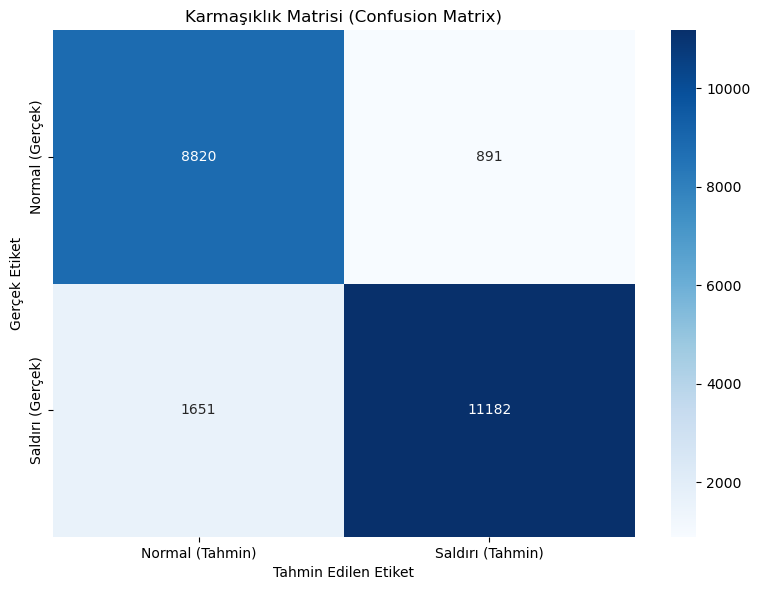

In [7]:
# --- Tahmin ---
y_pred = (test_errors > best_threshold).astype(int)

# --- Metrikler ---
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr_final = fp / (fp + tn)

print("=" * 50)
print("   VAE ANOMALİ TESPİT MODELİ - SONUÇLAR")
print("=" * 50)
print(f"ROC-AUC    : {roc_auc_val:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"F1-Score   : {f1:.4f}")
print(f"FPR        : {fpr_final:.4f}")
print(f"Eşik Değeri: {best_threshold:.6f}")
print("=" * 50)

print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Saldırı']))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (Tahmin)', 'Saldırı (Tahmin)'],
            yticklabels=['Normal (Gerçek)', 'Saldırı (Gerçek)'])
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Etiket')
plt.xlabel('Tahmin Edilen Etiket')
plt.tight_layout()
plt.show()